# Checking SAE conditions

In this notebook we download an SAE and check whether our conditions hold

First, we check the pairwise condition on features

This code follows the tutorials from SAE-lens, thank you those people :)

In [1]:
from datasets import load_dataset
from transformer_lens import HookedTransformer
from sae_lens import SAE
import torch
import plotly.express as px
import matplotlib.pyplot as plt
import numpy as np
from tqdm import tqdm

if torch.backends.mps.is_available():
    device = "mps"
else:
    device = "cuda" if torch.cuda.is_available() else "cpu"

print(f"Device: {device}")

/Users/will/anaconda3/envs/saes/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Device: cpu


We load up some stuff, from gpt2-small, block 8 SAE

In [2]:
model = HookedTransformer.from_pretrained("gpt2-small", device=device)

# the cfg dict is returned alongside the SAE since it may contain useful information for analysing the SAE (eg: instantiating an activation store)
# Note that this is not the same as the SAEs config dict, rather it is whatever was in the HF repo, from which we can extract the SAE config dict
# We also return the feature sparsities which are stored in HF for convenience.
sae = SAE.from_pretrained(
    release="gpt2-small-res-jb",  # see other options in sae_lens/pretrained_saes.yaml
    sae_id="blocks.8.hook_resid_pre",  # won't always be a hook point
    device=device,
)

Loading weights: 100%|███████████████████████████████████████████████████████████████████████| 148/148 [00:00<00:00, 7494.44it/s]


Loaded pretrained model gpt2-small into HookedTransformer


/Users/will/anaconda3/envs/saes/lib/python3.14/site-packages/sae_lens/saes/sae.py:251: UserWarning: 
This SAE has non-empty model_from_pretrained_kwargs. 
For optimal performance, load the model like so:
model = HookedSAETransformer.from_pretrained_no_processing(..., **cfg.model_from_pretrained_kwargs)
  warnings.warn(


In [3]:
print(sae.cfg)

StandardSAEConfig(d_in=768, d_sae=24576, dtype='float32', device='cpu', apply_b_dec_to_input=True, normalize_activations='none', reshape_activations='none', metadata=SAEMetadata({'sae_lens_version': '6.44.2', 'sae_lens_training_version': None, 'model_name': 'gpt2-small', 'hook_name': 'blocks.8.hook_resid_pre', 'hook_head_index': None, 'dataset_path': 'Skylion007/openwebtext', 'context_size': 128, 'model_from_pretrained_kwargs': {'center_writing_weights': True}, 'neuronpedia_id': 'gpt2-small/8-res-jb', 'prepend_bos': True}))


In [4]:
# We use the pile-10k dataset
from transformer_lens.utils import tokenize_and_concatenate

dataset = load_dataset(
    path="NeelNanda/pile-10k",
    #path="Skylion007/openwebtext",
    split="train",
    streaming=False,
)

token_dataset = tokenize_and_concatenate(
    dataset=dataset,  # type: ignore
    tokenizer=model.tokenizer,  # type: ignore
    streaming=True,
    max_length=sae.cfg.metadata.context_size,
    add_bos_token=sae.cfg.metadata.prepend_bos,
)

average l0 70.13693237304688


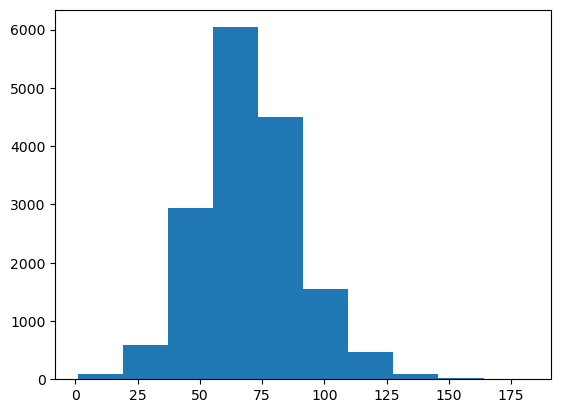

In [5]:
# We evaluate the SAE, don't push the dataset too big if working on a laptop!

sae.eval()  # prevents error if we're expecting a dead neuron mask for who grads

with torch.no_grad():
    # activation store can give us tokens.
    batch_tokens = token_dataset[:128]["tokens"]
    _, cache = model.run_with_cache(batch_tokens, prepend_bos=True)

    # Use the SAE
    feature_acts = sae.encode(cache[sae.cfg.metadata.hook_name])
    sae_out = sae.decode(feature_acts)

    # save some room
    del cache

    # ignore the bos token, get the number of features that activated in each token, averaged accross batch and position
    l0 = (feature_acts[:, 1:] > 0).float().sum(-1).detach()
    print("average l0", l0.mean().item())
    plt.hist(l0.flatten().cpu().numpy())

dictionary = sae.W_dec.detach().numpy()

/var/folders/7s/qvjsjmdx0xz163b26_jzw9300000gn/T/ipykernel_96638/252313825.py:8: RuntimeWarning: invalid value encountered in divide
  scaled_oriented_features = np.divide(mean_zero_reps, np.abs(np.min(mean_zero_reps, axis = 1))[:,None])


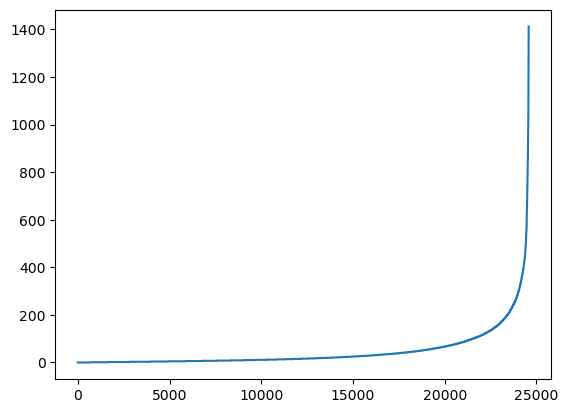

In [6]:
# Now we correctly squash and normalise the darta for downstream analysis
neurons_by_activity = np.argsort(np.sum((feature_acts > 0).numpy(), axis = (0,1)))
squashed_neural_reps = np.reshape(np.moveaxis(feature_acts.numpy(), [2], [0]), [feature_acts.shape[2], feature_acts.shape[0]*feature_acts.shape[1]])
activity_per_neuron = np.sum(squashed_neural_reps, axis = 1)
#subselect_neural_reps = squashed_neural_reps[activity_per_neuron>0, :]
neurons_by_activity = np.argsort(np.sum(squashed_neural_reps > 0, axis = 1))[::-1]
mean_zero_reps = squashed_neural_reps - np.mean(squashed_neural_reps, axis = 1)[:,None]
scaled_oriented_features = np.divide(mean_zero_reps, np.abs(np.min(mean_zero_reps, axis = 1))[:,None])
plt.plot(np.sort(np.sum(squashed_neural_reps > 0.001, axis = 1)))

9858 9303


(-1.1, 1.1)

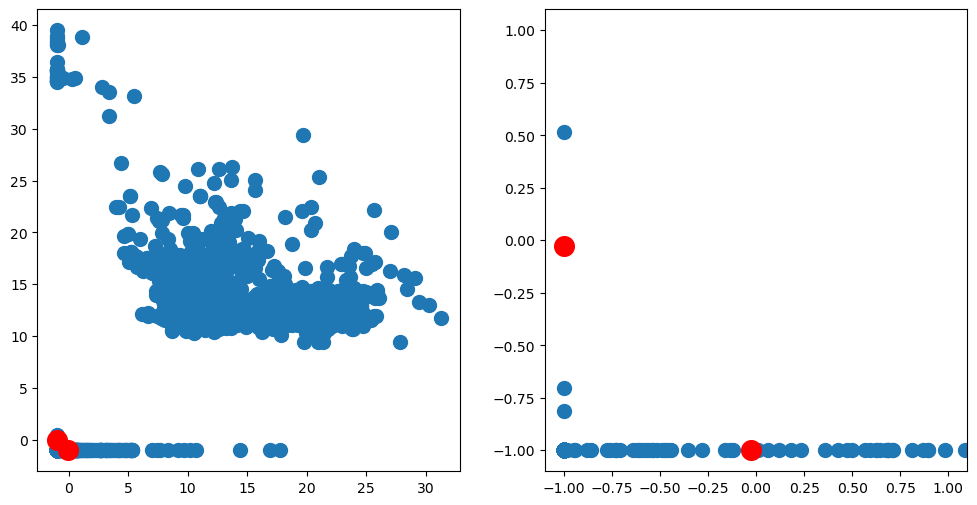

In [13]:
# Here you can zoom into a single pair of features, and extract their numbers for looking at them on neuronpedia
indices = [11, 17]


plt.figure(figsize = (12, 6))
plt.subplot(1,2,1)
plt.scatter(scaled_oriented_features[neurons_by_activity[indices[0]],:], scaled_oriented_features[neurons_by_activity[indices[1]],:], s = 100)

cosine_sim = np.dot(dictionary[indices[0],:], dictionary[indices[1],:])
plt.scatter(-1*cosine_sim, -1, c = 'red', s = 200)
plt.scatter(-1, -1*cosine_sim, c = 'red', s = 200)

#plt.ylim([-1, 1])

print(neurons_by_activity[indices[0]], neurons_by_activity[indices[1]])

plt.subplot(1,2,2)
plt.scatter(scaled_oriented_features[neurons_by_activity[indices[0]],:], scaled_oriented_features[neurons_by_activity[indices[1]],:], s = 100)

cosine_sim = np.dot(dictionary[indices[0],:], dictionary[indices[1],:])
plt.scatter(-1*cosine_sim, -1, c = 'red', s = 200)
plt.scatter(-1, -1*cosine_sim, c = 'red', s = 200)

plt.ylim([-1.1, 1.1])
plt.xlim([-1.1, 1.1])


In [41]:
sum(squashed_neural_reps[neurons_by_activity[590],:]> 0)

np.int64(439)

  6%|█████▍                                                                                    | 96/1580 [00:01<00:31, 46.66it/s]

Yello!


 14%|████████████                                                                             | 215/1580 [00:07<01:37, 14.00it/s]

Yello!
Yello!
Yello!
Yello!
Yello!


 14%|████████████▎                                                                            | 219/1580 [00:07<01:36, 14.06it/s]

...

 17%|██████████████▋                                                                          | 261/1580 [00:10<02:01, 10.82it/s]

Yello!
Yello!
Yello!
Yello!
Yello!


 89%|██████████████████████████████████████████████████████████████████████████████▌         | 1411/1580 [05:13<01:13,  2.29it/s]

Yello!


100%|████████████████████████████████████████████████████████████████████████████████████████| 1580/1580 [06:34<00:00,  4.00it/s]


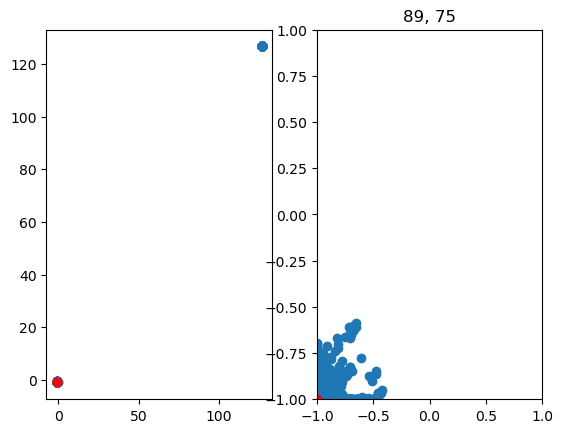

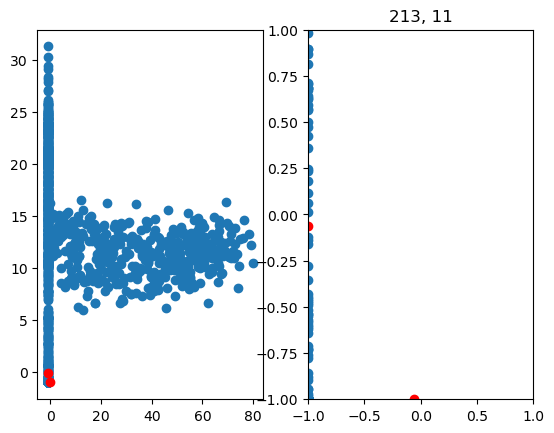

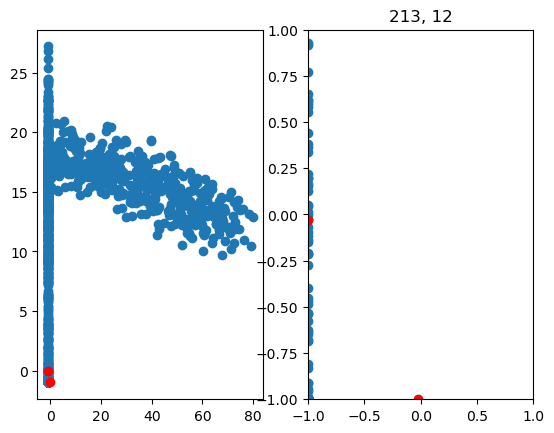

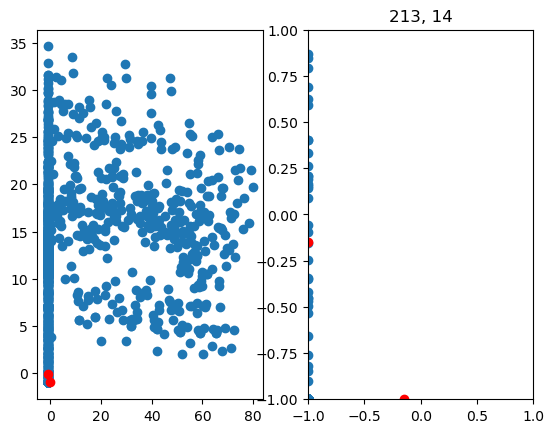

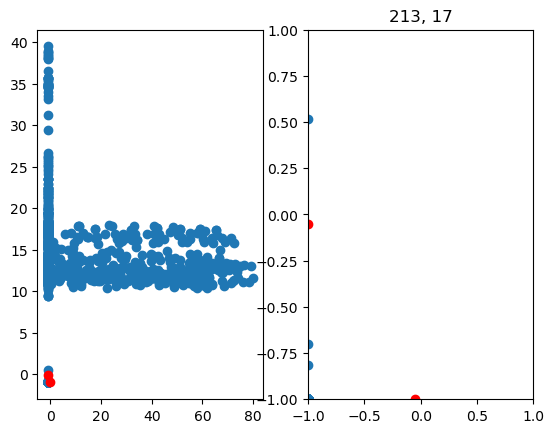

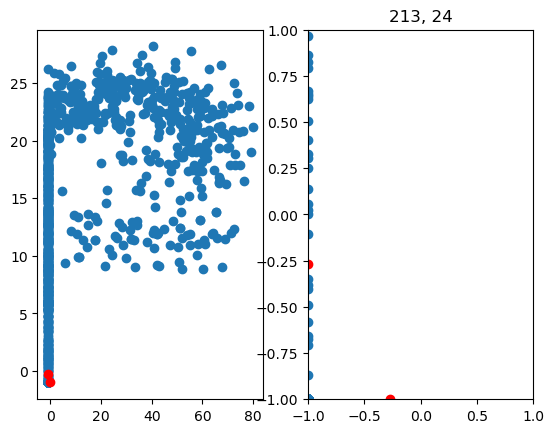

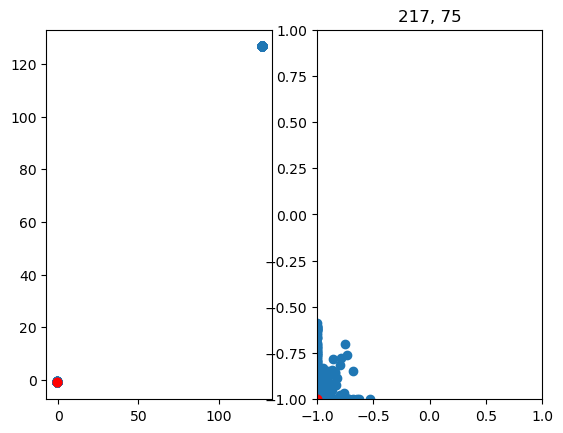

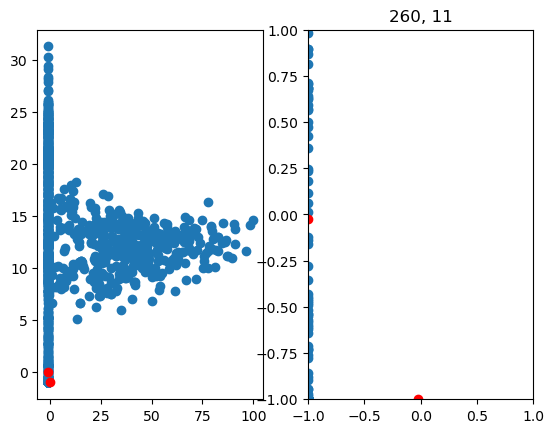

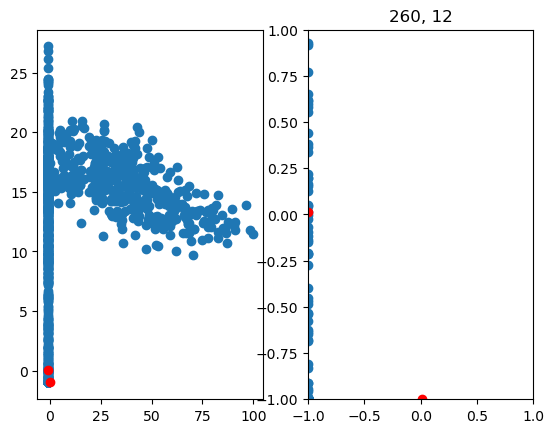

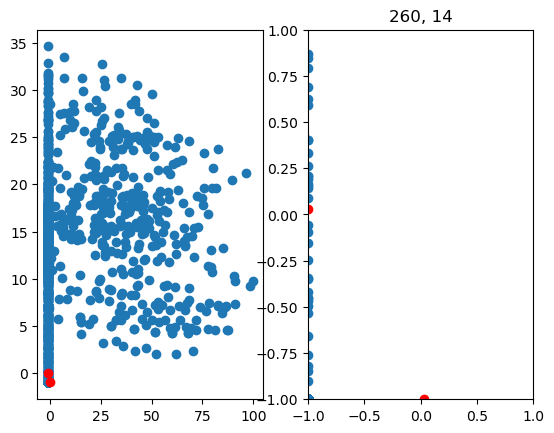

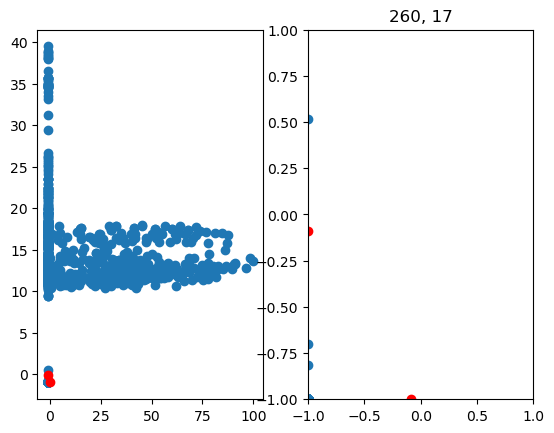

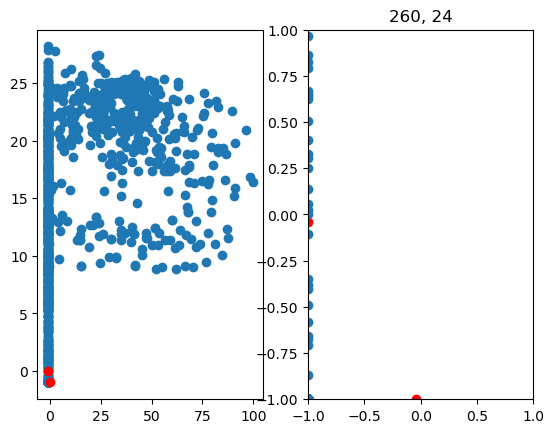

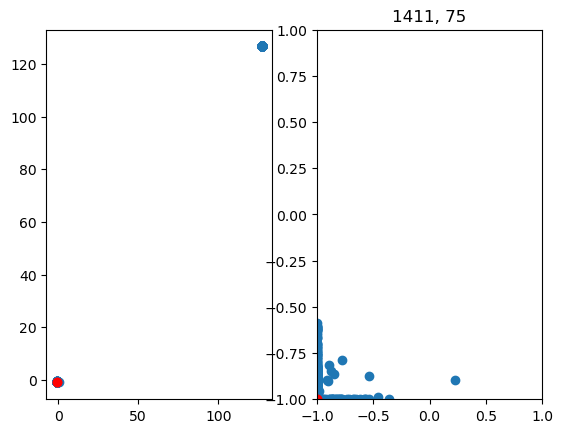

In [9]:
# Now we run the big search through all pairs of features that activate at least cutoff times.
# The fudge factor is to deal with the equality, previously perfectly aligned features (of which there are a surprising number) were coming up as errors, which they're not
cutoff = 0.01*int(squashed_neural_reps.shape[1])
fudge_thresh = 1.001 # Else you pick up very aligned cases
num_to_run = np.sum(np.sum(squashed_neural_reps > 0, axis = 1) > cutoff)

checks = np.zeros([num_to_run, num_to_run])


for first_var in tqdm(range(num_to_run)):
    for second_var in range(first_var):
        flag = 0
        x_feature = scaled_oriented_features[neurons_by_activity[first_var],:]
        y_feature = scaled_oriented_features[neurons_by_activity[second_var],:]
        
        inactive_x_where = x_feature == -1
        y_when_x_inactive = y_feature[inactive_x_where]

        if -1*cosine_sim > fudge_thresh*np.max(y_when_x_inactive) or -1*cosine_sim < fudge_thresh*np.min(y_when_x_inactive):
            flag = 1
            
        inactive_y_where = y_feature == -1
        x_when_y_inactive = x_feature[inactive_y_where]

        if -1*cosine_sim > fudge_thresh*np.max(x_when_y_inactive) or -1*cosine_sim < fudge_thresh*np.min(x_when_y_inactive):
            flag = 1

        if flag == 1:
            print('Yello!')
            plt.figure()
            plt.subplot(1,2,1)
            plt.scatter(scaled_oriented_features[neurons_by_activity[first_var],:], scaled_oriented_features[neurons_by_activity[second_var],:])
            cosine_sim = np.dot(dictionary[neurons_by_activity[first_var],:], dictionary[neurons_by_activity[second_var],:])
            plt.scatter(-1*cosine_sim, -1, c = 'red')
            plt.scatter(-1, -1*cosine_sim, c = 'red')

            plt.subplot(1,2,2)
            plt.scatter(scaled_oriented_features[neurons_by_activity[first_var],:], scaled_oriented_features[neurons_by_activity[second_var],:])
            plt.scatter(-1*cosine_sim, -1, c = 'red')
            plt.scatter(-1, -1*cosine_sim, c = 'red')
            plt.xlim([-1, 1])
            plt.ylim([-1,1])

            plt.title(f'{first_var}, {second_var}')

        checks[first_var, second_var] = flag

In [85]:
num_to_run*(num_to_run-1)/2

np.float64(7130976.0)

In [34]:
scaled_oriented_features.shape

(24576, 25600)

In [57]:
print(np.sum(checks))

1.0
